## **Importing the necessary Libraries.**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
import warnings
warnings.filterwarnings('ignore')

**1.1.** Reading in the data.

In [ ]:
cis_ml= pd.read_csv("./cis_data_cleaned_for_ml.csv")
cis_ml.head()

,year,geography,weight,gender,education,immigrant_status,earnings,wages_salary,total_income,region
0,2018,Ontario,208.9708,Female,Postsecondary certificate or diploma,Born in Canada (non-immigrant),50000.0,50000.0,50125.0,Ontario
1,2018,Ontario,208.9708,Male,University degree,Born in Canada (non-immigrant),49000.0,49000.0,49225.0,Ontario
2,2018,British Columbia,1101.2217,Female,University degree,Born in Canada (non-immigrant),92500.0,92500.0,93900.0,Rest of Canada
3,2018,British Columbia,1101.2217,Female,University degree,Born in Canada (non-immigrant),49000.0,0.0,49375.0,Rest of Canada
4,2018,Saskatchewan,165.3016,Female,High school diploma,Born in Canada (non-immigrant),21000.0,0.0,21000.0,Rest of Canada


**1.2.** Creating a copy of the data.

In [ ]:
df = cis_ml.copy()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102896 entries, 0 to 102895
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   year              102896 non-null  int64  
 1   geography         102896 non-null  object 
 2   weight            102896 non-null  float64
 3   gender            102896 non-null  object 
 4   education         102896 non-null  object 
 5   immigrant_status  102895 non-null  object 
 6   earnings          102895 non-null  float64
 7   wages_salary      102895 non-null  float64
 8   total_income      102895 non-null  float64
 9   region            102895 non-null  object 
dtypes: float64(4), int64(1), object(5)
memory usage: 7.9+ MB


**1.3.** Creating a new column called "Income Level" from the "total income" column

**1.3.1.** Removing invalid income values.

In [ ]:
df= df[df['total_income'].notna()]
df= df[df['total_income'] > 0]
df.head()

,year,geography,weight,gender,education,immigrant_status,earnings,wages_salary,total_income,region
0,2018,Ontario,208.9708,Female,Postsecondary certificate or diploma,Born in Canada (non-immigrant),50000.0,50000.0,50125.0,Ontario
1,2018,Ontario,208.9708,Male,University degree,Born in Canada (non-immigrant),49000.0,49000.0,49225.0,Ontario
2,2018,British Columbia,1101.2217,Female,University degree,Born in Canada (non-immigrant),92500.0,92500.0,93900.0,Rest of Canada
3,2018,British Columbia,1101.2217,Female,University degree,Born in Canada (non-immigrant),49000.0,0.0,49375.0,Rest of Canada
4,2018,Saskatchewan,165.3016,Female,High school diploma,Born in Canada (non-immigrant),21000.0,0.0,21000.0,Rest of Canada


**1.3.2.** Splitting the training and testing dataset by Region.

In [ ]:
train_df = df[df['region']=="Ontario"].copy()
test_df = df[df['region'] == "Rest of Canada"].copy()

**1.3.3.** Creating the Ontario-based income cutoffs.

**1.3.3.1.** Creating the tertile cutoffs.

In [ ]:
quantile_1 = train_df['total_income'].quantile(1/3) #Low Boundary
quantile_2 = train_df['total_income'].quantile(2/3) #Medium Boundary

**1.3.3.2.** Using the Ontario cutoffs to label both the training and testing dataset.

This is because we are using Ontario as a reference scale to evaluate whether Ontario-based income structures generalizes with to the rest of Canada.

In [ ]:
def label_income(x):
  if x <= quantile_1:
    return 'Low'
  elif quantile_1 < x <= quantile_2:
    return 'Medium'
  else:
    return 'High'

In [ ]:
train_df['income_level'] = train_df['total_income'].apply(label_income)
test_df['income_level'] = test_df['total_income'].apply(label_income)

In [ ]:
print(train_df['income_level'].value_counts(dropna= False))
print()
print(test_df['income_level'].value_counts(dropna= False))

income_level
Low       9674
High      9668
Medium    9661
Name: count, dtype: int64

income_level
Medium    25608
Low       24664
High      21926
Name: count, dtype: int64


In [ ]:
print(train_df.info())
print()
print(test_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 29003 entries, 0 to 102878
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              29003 non-null  int64  
 1   geography         29003 non-null  object 
 2   weight            29003 non-null  float64
 3   gender            29003 non-null  object 
 4   education         29003 non-null  object 
 5   immigrant_status  29003 non-null  object 
 6   earnings          29003 non-null  float64
 7   wages_salary      29003 non-null  float64
 8   total_income      29003 non-null  float64
 9   region            29003 non-null  object 
 10  income_level      29003 non-null  object 
dtypes: float64(4), int64(1), object(6)
memory usage: 2.7+ MB
None

<class 'pandas.core.frame.DataFrame'>
Index: 72198 entries, 2 to 102894
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year        

# **2.0.** Machine Learning Preprocessing.

##**2.1.** Defining the features and Targets variable.

In [ ]:
X = train_df.drop(columns=['total_income','income_level', 'geography', 'region'])
y_reg = train_df['total_income']
y_clf = train_df['income_level']

In [ ]:
X.columns

Index(['year', 'weight', 'gender', 'education', 'immigrant_status', 'earnings',
       'wages_salary'],
      dtype='object')

In [ ]:
numeric_features = ["year", "weight", "earnings", "wages_salary"]
categorical_features = ["gender", "education", "immigrant_status"]

## **2.2.** Splitting the training data into training and validation data.

### **2.2.1.** **For Regression.**

In [ ]:
X_train_reg, X_val_reg, y_train_reg, y_val_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)

### **2.2.2.** **For Classification.**

Using Stratify because it helps to keep proportion balanced.

In [ ]:
X_train_clf, X_val_clf, y_train_clf, y_val_clf = train_test_split(X, y_clf, test_size=0.2, random_state=42, stratify = y_clf)

## **2.3.** Building the preprocessor for encoding our categorical values and scaling our Numerical values.

- The **Pipeline** is used to combine preprocessing steps (encoding and scaling) and model training into a single object, instead of writing them as seperate code blocks.

- This helps to ensure that preprocessing is learned only from the training data and then applied to the validation and test data which helps prevent data leakage.

- The **Column Transformer** is used to apply different preprocessing methods to different groups of columns at the same time.

- This makes preprocessing step cleaner, faster and easier to manage within the machine learning pipeline.

### **2.3.1.** For the numeric values we Scale.
- Scaling is applied to numeric features to ensure that all values are on a comparable range, preventing the model from giving too much importance to large numbers just because they are big.

In [ ]:
numeric_transformer = Pipeline(steps=[
    ('scaler', MinMaxScaler())
])

### **2.3.2.** For the Categorical values we Encode.
- One-Hot encoding is used to convert categories into Numerical format. Althrough there's a real world progression in Education, One-Hot encoding is applied to avoid forcing any false rank, thereby allowing the model to learn category effects directly from the data.

In [ ]:
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

### **2.3.3.** Combining both the numeric and categorical transformer together using the preprocessor.

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# **3.0.** Models Building.

## **3.1.** Full Model

#### Based on the requirement for this aspect of the project, we would be making use of all the models we've been thought in class for both Regression and Classification.


##### As this would also help to validate the reason why we are picking our model.

**Column transfer** - Helps to apply different preprocessing to different sets of columns at the same time.

**Pipeline:** - Cleans the data using the Preprocessor, Then proceeds to train the model.

## **3.1.1.** Regression Models.

### **3.1.1.1.** Training and Validating the Regression Models and Creating a dataframe to store the results.

For the regression model we evaluate performance using R², Mean Absolute Error(MAE), and Root Mean Squared Error (RMSE).

- **R²**: Tells us how well the model explains income differences.

- **MAE**: Tells us how wrong the model is on average.

- **RMSE**: Tells us if the model sometimes makes very big mistakes.

In [ ]:
regression_models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regression": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42, n_estimators=200, n_jobs= -1),
    "K-Nearest Neighbours": KNeighborsRegressor(n_neighbors = 10),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42, n_estimators=150,learning_rate=0.1, max_depth=3)
}

regression_results = []
regression_pipes = {}

for name, model in regression_models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])


    #Training the models
    pipe.fit(X_train_reg, y_train_reg)

    #Training Prediction
    train_pred = pipe.predict(X_train_reg)

    #Validation Prediction
    val_pred = pipe.predict(X_val_reg)

    #scores
    train_r2 = r2_score(y_train_reg, train_pred)
    val_r2 = r2_score(y_val_reg, val_pred)

    train_mae = mean_absolute_error(y_train_reg, train_pred)
    val_mae = mean_absolute_error(y_val_reg, val_pred)

    train_rmse = np.sqrt(mean_squared_error(y_train_reg, train_pred))
    val_rmse = np.sqrt(mean_squared_error(y_val_reg, val_pred))

    regression_results.append([name, train_r2, val_r2, train_mae, val_mae, train_rmse, val_rmse])
    regression_pipes[name] = pipe

regression_results_table = pd.DataFrame(regression_results, columns = ['Model', 'Train R2', 'Val R2', 'Train MAE', 'Val MAE', 'Train RMSE', 'Val RMSE'])
regression_results_table = regression_results_table.round(4).sort_values(by='Val R2', ascending=False)
regression_results_table

,Model,Train R2,Val R2,Train MAE,Val MAE,Train RMSE,Val RMSE
4,Gradient Boosting,0.7932,0.7841,12786.4980,12612.3352,24523.5206,24865.0085
0,Linear Regression,0.7266,0.7414,16375.0806,15890.8555,28195.8878,27215.0143
2,Random Forest,0.9572,0.7403,5529.0659,14010.4098,11161.7016,27270.4003
3,K-Nearest Neighbours,0.7356,0.6876,13766.1430,14733.4761,27726.5114,29912.0701
1,Decision Tree Regression,0.9933,0.5854,375.9049,16831.3545,4403.8788,34457.9532


### **3.1.1.2.** Testing the Best Regression Model (Selected from Validation).

In [ ]:
best_reg_model= regression_results_table.iloc[0]['Model']
best_reg_pipe = regression_pipes[best_reg_model]

X_test = test_df.drop(columns=['total_income','income_level', 'geography', 'region'])
y_test_reg = test_df['total_income']

test_predict = best_reg_pipe.predict(X_test)

test_r2 = r2_score(y_test_reg, test_predict)
test_mae = mean_absolute_error(y_test_reg, test_predict)
test_rmse = np.sqrt(mean_squared_error(y_test_reg, test_predict))
reg_scores = []
reg_scores.append([best_reg_model, test_r2, test_mae, test_rmse])

print("Best Model:", best_reg_model)
print("Test R2:", test_r2)
print("Test MAE", test_mae)
print("Test RMSE", test_rmse)


test_result_df = pd.DataFrame(reg_scores, columns = ['Model', 'Test R2', 'Test MAE', 'Test RMSE'])
test_result_df

Best Model: Gradient Boosting
Test R2: 0.7828357371896473
Test MAE 12166.14127123086
Test RMSE 21971.522191748187


,Model,Test R2,Test MAE,Test RMSE
0,Gradient Boosting,0.782836,12166.141271,21971.522192


Gradient Boosting achieved the highest validation and test performance for both the full and structural models in Canada and the United States. This indicates that income prediction is driven by complex, non-linear relationships that are better captured by ensemble boosting methods than by single models.

# **3.1.2.** Classification Models.

### **3.1.2.1.** Training and Validating the Classification Models and Creating a dataframe to store the results.

In [ ]:
classification_models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=10),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=200, max_depth=15, n_jobs=-1),
    "KNN": KNeighborsClassifier(n_neighbors=15),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42, n_estimators=150, learning_rate=0.1, max_depth=3)
}

clf_val_rows = []
clf_pipes = {}

for name, model in classification_models.items():

    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train_clf, y_train_clf)

    # Training predictions
    train_pred = pipe.predict(X_train_clf)
    val_pred = pipe.predict(X_val_clf)

    train_acc = accuracy_score(y_train_clf, train_pred)
    val_acc = accuracy_score(y_val_clf, val_pred)

    train_f1 = f1_score(y_train_clf, train_pred, average="weighted")
    val_f1 = f1_score(y_val_clf, val_pred, average="weighted")

    train_precision = precision_score(y_train_clf, train_pred, average="weighted")
    val_precision = precision_score(y_val_clf, val_pred, average="weighted")

    train_recall = recall_score(y_train_clf, train_pred, average="weighted")
    val_recall = recall_score(y_val_clf, val_pred, average="weighted")

    clf_val_rows.append([name, train_acc, val_acc, train_f1, val_f1, train_precision, val_precision, train_recall, val_recall])
    clf_pipes[name] = pipe

clf_val_table = pd.DataFrame(
    clf_val_rows,
    columns=["Model", "Train Accuracy", "Val Accuracy", "Train F1", "Val F1", "Train Precision", "Val Precision", "Train Recall", "Val Recall"]
)

clf_val_table = clf_val_table.sort_values(by="Val F1", ascending=False)
clf_val_table

,Model,Train Accuracy,Val Accuracy,Train F1,Val F1,Train Precision,Val Precision,Train Recall,Val Recall
4,Gradient Boosting,0.788251,0.791588,0.788051,0.791420,0.813049,0.810831,0.788251,0.791588
2,Random Forest,0.870313,0.787968,0.870976,0.787652,0.886288,0.803060,0.870313,0.787968
1,Decision Tree,0.797130,0.786416,0.797154,0.785532,0.820104,0.802190,0.797130,0.786416
3,KNN,0.761227,0.737976,0.761058,0.737828,0.775480,0.749125,0.761227,0.737976
0,Logistic Regression,0.682398,0.684020,0.676611,0.676951,0.682409,0.681016,0.682398,0.684020


### **3.1.2.2.** Testing the Classification Model and Creating a dataframe to store the results.

In [ ]:
best_clf_model = clf_val_table.iloc[0]['Model']
best_clf_pipes = clf_pipes[best_clf_model]

X_test_clf = test_df.drop(columns=["total_income", "income_level", "geography", "region"], errors="ignore")
y_test_clf = test_df["income_level"]

test_pred = best_clf_pipes.predict(X_test_clf)
test_acc = accuracy_score(y_test_clf, test_pred)
test_f1 = f1_score(y_test_clf, test_pred, average="weighted")
test_precision = precision_score(y_test_clf, test_pred, average="weighted")
test_recall = recall_score(y_test_clf, test_pred, average="weighted")

classification_test_scores = []


classification_test_scores.append([best_clf_model, test_acc, test_f1, test_precision, test_recall])


print("Best Classification Model", best_clf_model)
print(f"Test Accuracy Score: {test_acc:.4f}")
print(f"Test F1 Score: {test_f1:.4f}")
print(f"Test Precision Score: {test_precision:.4f}")
print(f"Test Recall Score: {test_recall:.4f}")
print("Confusion Matrix:", confusion_matrix(y_test_clf, test_pred))
print("Classification Report:", classification_report(y_test_clf, test_pred))


test_results_df = pd.DataFrame(classification_test_scores, columns= ["Model", "Accuracy", "F1", "Precision", "Recall"])
test_results_df

Best Classification Model Gradient Boosting
Test Accuracy Score: 0.7689
Test F1 Score: 0.7680
Test Precision Score: 0.7866
Test Recall Score: 0.7689
Confusion Matrix: [[17229  1975  2722]
 [  579 22151  1934]
 [  868  8610 16130]]
Classification Report:               precision    recall  f1-score   support

        High       0.92      0.79      0.85     21926
         Low       0.68      0.90      0.77     24664
      Medium       0.78      0.63      0.70     25608

    accuracy                           0.77     72198
   macro avg       0.79      0.77      0.77     72198
weighted avg       0.79      0.77      0.77     72198



,Model,Accuracy,F1,Precision,Recall
0,Gradient Boosting,0.768858,0.768034,0.786561,0.768858


Gradient Boosting also achieved the best performance in the full classification models for both countries. This suggests that when all income-related variables are included, the relationship between features and income levels becomes more complex and benefits from advanced ensemble methods.

##**3.2.** Feature Importance For Full Model.

### **3.2.1.** **Extracting feature names after encoding**.

Because encoding increased the categorical variables that we have and we need to retrieve the transformed feature names.

In [ ]:
best_model = best_reg_pipe.named_steps['model']
preprocessor = best_reg_pipe.named_steps['preprocessor']

In [ ]:
feature_names = preprocessor.get_feature_names_out()
feature_importances = best_model.feature_importances_

**3.2.2. Extracting Feature Importance.**

In [ ]:
importances= best_model.feature_importances_

feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)
feature_imp_df.head(10)

,Feature,Importance
2,num__earnings,0.909474
3,num__wages_salary,0.059219
1,num__weight,0.015828
7,cat__education_University degree,0.010310
4,cat__gender_Male,0.002092
6,cat__education_Postsecondary certificate or di...,0.001584
8,cat__immigrant_status_Immigrant,0.000716
5,cat__education_Less than high school,0.000618
0,num__year,0.000160


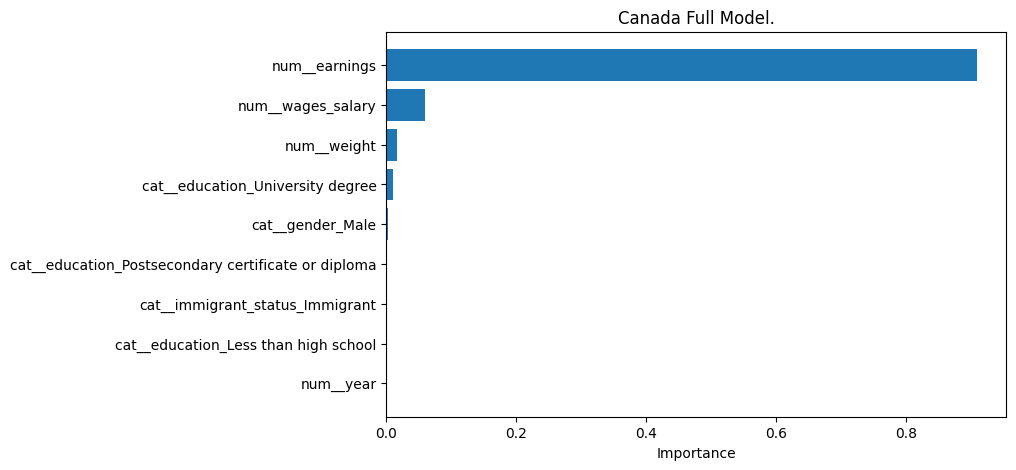

In [ ]:
top_features = feature_imp_df.head(10)

plt.figure(figsize=(8,5))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.title("Canada Full Model.")
plt.xlabel("Importance")
plt.show()

Feature importance was extracted from the best-performing full model. The results show that earnings-related variables dominate income prediction, accounting for most of the model’s explanatory power.

Even though the full model achieves strong predictive performance, it primarily captures the accounting relationships between earnings and total income.


This limits its usefulness for understanding structural labour market determinants such as education and immigrant status. Thereby not answering the question of if Immigration status affects how people earn despite the same educational degree.

## **3.3.** Structural Model.

To understand better demographic and immigrant labour market effects, we constructed a structural model excluding income component variables (earnings, wages and survey weight).

In [ ]:
structural_features = [
    "year",
    "gender",
    "education",
    "immigrant_status"
]

In [ ]:
X_struct = train_df[structural_features].copy()
y_struct_reg = train_df["total_income"].copy()
y_struct_clf = train_df["income_level"].copy()

In [ ]:
X_test_struct = test_df[structural_features].copy()
y_test_struct_reg = test_df["total_income"].copy()
y_test_struct_clf = test_df['income_level'].copy()

In [ ]:
X_train_struct_reg, X_val_struct_reg, y_train_struct_reg, y_val_struct_reg = train_test_split(X_struct, y_struct_reg, test_size=0.2, random_state=42)

In [ ]:
X_train_struct_clf, X_val_struct_clf, y_train_struct_clf, y_val_struct_clf = train_test_split(X_struct, y_struct_clf, test_size=0.2, random_state=42, stratify=y_struct_clf)

In [ ]:
numeric_features_struct = ["year"]
categorical_features_struct = ["gender", "education", "immigrant_status"]

In [ ]:
numeric_transformer_struct = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),   # safe even if no missing
    ("scaler", MinMaxScaler())
])

categorical_transformer_struct = Pipeline(steps=[
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor_struct = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_struct, numeric_features_struct),
        ("cat", categorical_transformer_struct, categorical_features_struct),
    ],
    remainder="drop"
)

### **3.3.1.** Regression.

### **3.3.1.1.** Training and Validating the Regression Model.

In [ ]:
reg_models_struct = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42, max_depth=10),
    "Random Forest": RandomForestRegressor(random_state=42, n_estimators=200, max_depth=15, n_jobs=-1),
    "KNN": KNeighborsRegressor(n_neighbors=10),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42, n_estimators=150, learning_rate=0.1, max_depth=3)
}

reg_rows = []
reg_pipes = {}

for name, model in reg_models_struct.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor_struct),
        ("model", model)
    ])
    pipe.fit(X_train_struct_reg, y_train_struct_reg)

    train_pred = pipe.predict(X_train_struct_reg)
    val_pred = pipe.predict(X_val_struct_reg)

    reg_rows.append({
        "Model": name,
        "Train R2": r2_score(y_train_struct_reg, train_pred),
        "Val R2": r2_score(y_val_struct_reg, val_pred),
        "Train MAE": mean_absolute_error(y_train_struct_reg, train_pred),
        "Val MAE": mean_absolute_error(y_val_struct_reg, val_pred),
        "Train RMSE": np.sqrt(mean_squared_error(y_train_struct_reg, train_pred)),
        "Val RMSE": np.sqrt(mean_squared_error(y_val_struct_reg, val_pred)),
    })
    reg_pipes[name] = pipe

reg_results_table = pd.DataFrame(reg_rows).round(4).sort_values(by="Val R2", ascending=False)
reg_results_table


,Model,Train R2,Val R2,Train MAE,Val MAE,Train RMSE,Val RMSE
1,Decision Tree,0.1381,0.1228,30072.2811,29210.2764,50063.1671,50121.8324
2,Random Forest,0.1381,0.1228,30067.8256,29206.7293,50063.3612,50121.6305
4,Gradient Boosting,0.1379,0.1224,30071.5585,29221.0711,50066.8283,50132.8645
0,Linear Regression,0.1320,0.1185,30187.0077,29414.0809,50240.0402,50245.7557
3,KNN,-0.0824,-0.0708,34467.6878,33491.0748,56101.6993,55376.3980


### **3.3.1.2.** Testing the Structual Model.

In [ ]:
best_reg_model_struct = reg_results_table.iloc[0]["Model"]
best_reg_pipe_struct = reg_pipes[best_reg_model_struct]

test_pred_reg = best_reg_pipe_struct.predict(X_test_struct)

reg_test_struct = pd.DataFrame([{
    "Best Model": best_reg_model_struct,
    "Test R2": r2_score(y_test_struct_reg, test_pred_reg),
    "Test MAE": mean_absolute_error(y_test_struct_reg, test_pred_reg),
    "Test RMSE": np.sqrt(mean_squared_error(y_test_struct_reg, test_pred_reg)),
}]).round(4)

print("\n=== STRUCTURAL REGRESSION (Test on Rest of Canada) ===")
display(reg_test_struct)


=== STRUCTURAL REGRESSION (Test on Rest of Canada) ===


,Best Model,Test R2,Test MAE,Test RMSE
0,Decision Tree,0.1343,28046.6794,43869.2514


### **3.3.2.** Classification.

### **3.3.2.1.** Training and Validating the Classification model.

In [ ]:
classification_models_s = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=10),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=200, max_depth=15, n_jobs=-1),
    "KNN": KNeighborsClassifier(n_neighbors=15),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42, n_estimators=150, learning_rate=0.1, max_depth=3)
}

clf_rows_s = []
clf_pipes_s = {}

for name, model in classification_models_s.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor_struct),
        ("model", model)
    ])

    pipe.fit(X_train_struct_clf, y_train_struct_clf)

    train_pred = pipe.predict(X_train_struct_clf)
    val_pred = pipe.predict(X_val_struct_clf)

    clf_rows_s.append({
        "Model": name,
        "Train Acc": accuracy_score(y_train_struct_clf, train_pred),
        "Val Acc": accuracy_score(y_val_struct_clf, val_pred),
        "Train F1": f1_score(y_train_struct_clf, train_pred, average="weighted"),
        "Val F1": f1_score(y_val_struct_clf, val_pred, average="weighted"),
    })

    clf_pipes_s[name] = pipe

clf_results_s = pd.DataFrame(clf_rows_s).round(4).sort_values(by="Val F1", ascending=False)
print()
print(" STRUCTURAL CLASSIFICATION (Train vs Val) ")
display(clf_results_s)


 STRUCTURAL CLASSIFICATION (Train vs Val) 


,Model,Train Acc,Val Acc,Train F1,Val F1
0,Logistic Regression,0.4948,0.4959,0.4817,0.4833
2,Random Forest,0.4956,0.4968,0.4737,0.4766
1,Decision Tree,0.4956,0.4956,0.4730,0.4741
4,Gradient Boosting,0.4956,0.4956,0.4730,0.4741
3,KNN,0.4301,0.4427,0.4174,0.4298


### **3.3.2.2.** Testing the Classification Model.

In [ ]:
best_clf_model_s = clf_results_s.iloc[0]["Model"]
best_clf_pipe_s = clf_pipes_s[best_clf_model_s]


test_pred_clf_s = best_clf_pipe_s.predict(X_test_struct)

print("\nBest Structural Classification Model:", best_clf_model_s)
print("Test Accuracy:", round(accuracy_score(y_test_struct_clf, test_pred_clf_s), 4))
print("Test F1:", round(f1_score(y_test_struct_clf, test_pred_clf_s, average="weighted"), 4))
print("Confusion Matrix:\n", confusion_matrix(y_test_struct_clf, test_pred_clf_s))
print("\nClassification Report:\n", classification_report(y_test_struct_clf, test_pred_clf_s))


Best Structural Classification Model: Logistic Regression
Test Accuracy: 0.4922
Test F1: 0.4767
Confusion Matrix:
 [[14506  3972  3448]
 [ 5469 14087  5108]
 [ 9649  9018  6941]]

Classification Report:
               precision    recall  f1-score   support

        High       0.49      0.66      0.56     21926
         Low       0.52      0.57      0.54     24664
      Medium       0.45      0.27      0.34     25608

    accuracy                           0.49     72198
   macro avg       0.49      0.50      0.48     72198
weighted avg       0.49      0.49      0.48     72198



In contrast, structural classification models produced different results across countries. Logistic Regression performed best in Canada, indicating more linear relationships between demographic variables and income levels. In the United States, Decision Tree performed best, suggesting more non-linear segmentation in how demographic factors influence income.

###**3.4. Feature Importance For Structural Model.**

For structural interpretation, Logistic Regression was used because it provides coefficients that show the relative influence of each factor more clearly than tree-based models.

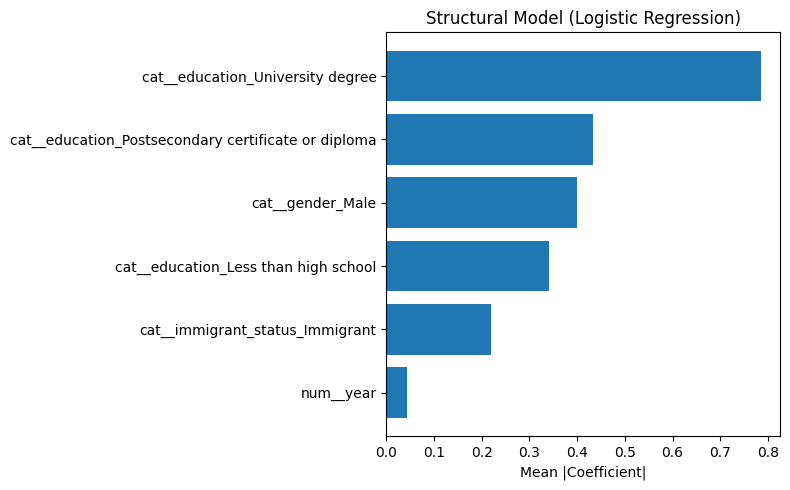

In [ ]:
logistic_pipe = clf_pipes_s["Logistic Regression"]

clf_model = logistic_pipe.named_steps["model"]
preprocessor = logistic_pipe.named_steps["preprocessor"]

feature_names = preprocessor.get_feature_names_out()

# Get coefficients
coefs = clf_model.coef_

# Convert to overall importance
importance = np.mean(np.abs(coefs), axis=0)

feature_imp_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

top_features = feature_imp_df.head(10)

plt.figure(figsize=(8,5))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.title("Structural Model (Logistic Regression)")
plt.xlabel("Mean |Coefficient|")
plt.tight_layout()
plt.show()

This chart answers the question:

**When earnings and wage variables are removed, what factors help the model classify individuals into Low, Medium, or High income groups?**

The results show that education is the strongest structural determinant of income classification, with a university degree having the largest influence. Other education levels also contribute meaningfully to income grouping.

Gender has a moderate effect on income classification.

Immigrant status does influence income level, but its impact is smaller compared to education.

Overall, this indicates that in the structural model for Canada, education is a stronger driver of income level than immigrant status, although immigrant status still plays a measurable role.

## **4.0.** Bridging the Gap.

### **4.1. Does immigrant status push one's income towards Low, Medium or High Income level?**

Using Logistic regression because it provides directional coefficients, which allows us to see if Immigrant status increases or decreases the probability of being in a Low, Medium or High Income group.

In [ ]:
logistic_pipe = clf_pipes_s["Logistic Regression"]

clf_model = logistic_pipe.named_steps["model"]
preprocessor = logistic_pipe.named_steps["preprocessor"]

feature_names = preprocessor.get_feature_names_out()

coef_df = pd.DataFrame(
    clf_model.coef_,
    columns=feature_names,
    index=clf_model.classes_
)

# Look specifically at immigrant effect
coef_df[["cat__immigrant_status_Immigrant"]]

,cat__immigrant_status_Immigrant
High,-0.328897
Low,0.262801
Medium,0.066096


In the structural model, being an immigrant increases the likelihood of being in the low income group and decreases the likelihood of being in the high income group.

This analysis examines whether immigrant status pushes individuals toward Low, Medium, or High income categories.

The Logistic Regression results show that:

Immigrant status has a positive association with the Low-income group.

It has a negative association with the High-income group.

The effect on the Medium-income group is relatively small.

This means that, after accounting for structural factors such as education and gender, being an immigrant increases the likelihood of being classified in the Low-income group and decreases the likelihood of being in the High-income group.

### **4.2. Does Education reduce the income gap between immigrants and native born individuals?**

In [ ]:
income_comparison = (
    train_df
    .groupby(["education", "immigrant_status"])["total_income"]
    .mean()
    .reset_index()
)

income_comparison

,education,immigrant_status,total_income
0,High school diploma,Born in Canada (non-immigrant),39074.918994
1,High school diploma,Immigrant,36403.444676
2,Less than high school,Born in Canada (non-immigrant),29714.712192
3,Less than high school,Immigrant,29623.901809
4,Postsecondary certificate or diploma,Born in Canada (non-immigrant),56352.390956
5,Postsecondary certificate or diploma,Immigrant,48088.883820
6,University degree,Born in Canada (non-immigrant),79634.855602
7,University degree,Immigrant,67629.942857


In [ ]:
income_pivot = income_comparison.pivot(
    index="education",
    columns="immigrant_status",
    values="total_income"
)

income_pivot

immigrant_status,Born in Canada (non-immigrant),Immigrant
education,,
High school diploma,39074.918994,36403.444676
Less than high school,29714.712192,29623.901809
Postsecondary certificate or diploma,56352.390956,48088.883820
University degree,79634.855602,67629.942857


In [ ]:
income_pivot["Income_Gap"] = (
    income_pivot["Born in Canada (non-immigrant)"] -
    income_pivot["Immigrant"]
)

income_pivot

immigrant_status,Born in Canada (non-immigrant),Immigrant,Income_Gap
education,,,
High school diploma,39074.918994,36403.444676,2671.474318
Less than high school,29714.712192,29623.901809,90.810383
Postsecondary certificate or diploma,56352.390956,48088.883820,8263.507136
University degree,79634.855602,67629.942857,12004.912745


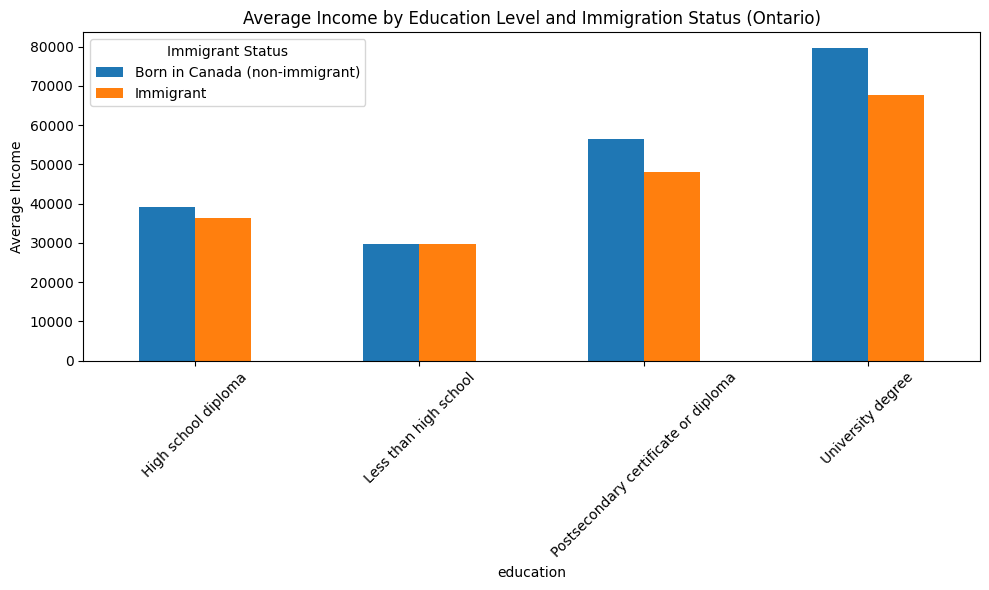

In [ ]:
income_pivot[["Born in Canada (non-immigrant)", "Immigrant"]].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Average Income by Education Level and Immigration Status (Ontario)")
plt.ylabel("Average Income")
plt.xticks(rotation=45)
plt.legend(title="Immigrant Status")
plt.tight_layout()
plt.show()

While education increases average income for both immigrants and Canadian-born individuals, the income gap does not disappear at higher education levels. In fact, the gap widens at the university degree level in Ontario.

### **Cross Country Structural Comparison.**

Ignore this table fro now, I need to update it with the new values.

| Metric                                 | Canada     | US            |
| -------------------------------------- | ---------- | ------------- |
| Structural R² (Regression)             | 0.1303         | 0.1199            |
| Structural Accuracy (Classification)   | 0.4931         | 0.4905            |
| Immigrant Status Pushes Toward         | Stronger towards Low Income | Moderate towards Medium Income |
| Education Strongest Predictor?         | Yes        | Yes           |
| Income Gap Widens at University Level? | Yes        | No      |


## **CONCLUSION.**

In this study, we looked at how education and immigrant status affect income levels in Canada and the United States.

In both countries, education is the strongest factor. People with a university degree are much more likely to be in the High-income group.

Immigrant status does affect income, but its impact is smaller than education. In Canada, immigrants are more likely to be classified in the Low-income group and less likely to be in the High-income group, even after considering education and gender.

In the United States, the effect of immigrant status is weaker and not as consistent across income levels.

When we compare both countries, education plays the biggest role in determining income, but the size and direction of the immigrant income gap differ between Canada and the US.

Overall, this means that improving education may be one of the most important ways to reduce income inequality, but immigration-related income gaps still exist and behave differently across countries.

# **ANN- Using Tensor Flow**

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import LabelEncoder
import joblib

In [ ]:
tf.random.set_seed(42)
np.random.seed(42)

Structural Regression Data for ANN

In [ ]:
# Transform structural inputs for regression
X_train_reg_tf = preprocessor_struct.fit_transform(X_train_struct_reg)
X_val_reg_tf = preprocessor_struct.transform(X_val_struct_reg)
X_test_reg_tf = preprocessor_struct.transform(X_test_struct)

# Convert sparse matrices to dense arrays if needed
X_train_reg_tf = X_train_reg_tf.toarray() if hasattr(X_train_reg_tf, "toarray") else X_train_reg_tf
X_val_reg_tf = X_val_reg_tf.toarray() if hasattr(X_val_reg_tf, "toarray") else X_val_reg_tf
X_test_reg_tf = X_test_reg_tf.toarray() if hasattr(X_test_reg_tf, "toarray") else X_test_reg_tf

Build the ANN Regression Model.

In [ ]:
ann_reg = Sequential([
    Input(shape=(X_train_reg_tf.shape[1],)),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

In [ ]:
ann_reg.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [ ]:
early_stop_reg = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

Training the ANN Regression Model.

In [ ]:
history_reg = ann_reg.fit(
    X_train_reg_tf,
    y_train_struct_reg,
    validation_data=(X_val_reg_tf, y_val_struct_reg),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop_reg],
    verbose=0
)

Making Predicitions.

In [ ]:
train_pred_ann_reg = ann_reg.predict(X_train_reg_tf, verbose=0).flatten()
val_pred_ann_reg = ann_reg.predict(X_val_reg_tf, verbose=0).flatten()
test_pred_ann_reg = ann_reg.predict(X_test_reg_tf, verbose=0).flatten()

Evaluating Regression Performance.

In [ ]:
print("=== Canada TensorFlow Structural Regression ===")
print("Train R2:", round(r2_score(y_train_struct_reg, train_pred_ann_reg), 4))
print("Val R2:", round(r2_score(y_val_struct_reg, val_pred_ann_reg), 4))
print("Test R2:", round(r2_score(y_test_struct_reg, test_pred_ann_reg), 4))

print("Train MAE:", round(mean_absolute_error(y_train_struct_reg, train_pred_ann_reg), 4))
print("Val MAE:", round(mean_absolute_error(y_val_struct_reg, val_pred_ann_reg), 4))
print("Test MAE:", round(mean_absolute_error(y_test_struct_reg, test_pred_ann_reg), 4))

print("Train RMSE:", round(np.sqrt(mean_squared_error(y_train_struct_reg, train_pred_ann_reg)), 4))
print("Val RMSE:", round(np.sqrt(mean_squared_error(y_val_struct_reg, val_pred_ann_reg)), 4))
print("Test RMSE:", round(np.sqrt(mean_squared_error(y_test_struct_reg, test_pred_ann_reg)), 4))

=== Canada TensorFlow Structural Regression ===
Train R2: 0.1318
Val R2: 0.1187
Test R2: 0.1363
Train MAE: 30109.896
Val MAE: 29333.295
Test MAE: 27944.2903
Train RMSE: 50244.2846
Val RMSE: 50237.7944
Test RMSE: 43817.3021


Structural Classification Data.

In [ ]:
# Transform structural inputs for classification
X_train_clf_tf = preprocessor_struct.fit_transform(X_train_struct_clf)
X_val_clf_tf = preprocessor_struct.transform(X_val_struct_clf)
X_test_clf_tf = preprocessor_struct.transform(X_test_struct)

X_train_clf_tf = X_train_clf_tf.toarray() if hasattr(X_train_clf_tf, "toarray") else X_train_clf_tf
X_val_clf_tf = X_val_clf_tf.toarray() if hasattr(X_val_clf_tf, "toarray") else X_val_clf_tf
X_test_clf_tf = X_test_clf_tf.toarray() if hasattr(X_test_clf_tf, "toarray") else X_test_clf_tf

Encoding the target labels.

In [ ]:
label_encoder_can = LabelEncoder()
y_train_clf_enc = label_encoder_can.fit_transform(y_train_struct_clf)
y_val_clf_enc = label_encoder_can.transform(y_val_struct_clf)
y_test_clf_enc = label_encoder_can.transform(y_test_struct_clf)

num_classes = len(label_encoder_can.classes_)

Building the ANN Classification Model.

In [ ]:
ann_clf = Sequential([
    Input(shape=(X_train_clf_tf.shape[1],)),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(num_classes, activation="softmax")
])

Compiling the Classification Model.

In [ ]:
ann_clf.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Early stopping for Classification: When validation performance stops improving.

In [ ]:
early_stop_clf = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

Training the ANN Classifier.

In [ ]:
history_clf = ann_clf.fit(
    X_train_clf_tf,
    y_train_clf_enc,
    validation_data=(X_val_clf_tf, y_val_clf_enc),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop_clf],
    verbose=0
)

Making Classification Predictions.

In [ ]:
train_pred_probs = ann_clf.predict(X_train_clf_tf, verbose=0)
val_pred_probs = ann_clf.predict(X_val_clf_tf, verbose=0)
test_pred_probs = ann_clf.predict(X_test_clf_tf, verbose=0)

train_pred_ann_clf = np.argmax(train_pred_probs, axis=1)
val_pred_ann_clf = np.argmax(val_pred_probs, axis=1)
test_pred_ann_clf = np.argmax(test_pred_probs, axis=1)

Evaluate Classification Performance.

In [ ]:
print("=== Canada TensorFlow Structural Classification ===")
print("Train Accuracy:", round(accuracy_score(y_train_clf_enc, train_pred_ann_clf), 4))
print("Val Accuracy:", round(accuracy_score(y_val_clf_enc, val_pred_ann_clf), 4))
print("Test Accuracy:", round(accuracy_score(y_test_clf_enc, test_pred_ann_clf), 4))

print("Train F1:", round(f1_score(y_train_clf_enc, train_pred_ann_clf, average="weighted"), 4))
print("Val F1:", round(f1_score(y_val_clf_enc, val_pred_ann_clf, average="weighted"), 4))
print("Test F1:", round(f1_score(y_test_clf_enc, test_pred_ann_clf, average="weighted"), 4))

print("\nClassification Report (Test):")
print(classification_report(y_test_clf_enc, test_pred_ann_clf, target_names=label_encoder_can.classes_))

print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test_clf_enc, test_pred_ann_clf))

=== Canada TensorFlow Structural Classification ===
Train Accuracy: 0.4942
Val Accuracy: 0.4928
Test Accuracy: 0.4897
Train F1: 0.4689
Val F1: 0.4689
Test F1: 0.4647

Classification Report (Test):
              precision    recall  f1-score   support

        High       0.49      0.68      0.57     21926
         Low       0.50      0.61      0.55     24664
      Medium       0.47      0.22      0.30     25608

    accuracy                           0.49     72198
   macro avg       0.49      0.50      0.47     72198
weighted avg       0.49      0.49      0.46     72198


Confusion Matrix (Test):
[[14870  4749  2307]
 [ 5707 14926  4031]
 [10078  9968  5562]]


Saving the models for the application.

In [ ]:
joblib.dump(preprocessor_struct, "canada_tf_struct_preprocessor.pkl")
joblib.dump(label_encoder_can, "canada_tf_struct_label_encoder.pkl")

ann_reg.save("canada_tf_struct_regressor.keras")
ann_clf.save("canada_tf_struct_classifier.keras")

print("Canada TensorFlow structural models saved successfully.")

Canada TensorFlow structural models saved successfully.


In [ ]:
import joblib

joblib.dump(best_reg_pipe_struct, "canada_structural_regressor.pkl")
joblib.dump(best_clf_pipe_s, "canada_structural_classifier.pkl")
joblib.dump({"q1": quantile_1, "q2": quantile_2}, "canada_income_cutoffs.pkl")

['canada_income_cutoffs.pkl']

### **REGRESSION.**

| Metric                                 | Gradient Boosting     | ANN            |
| -------------------------------------- | ---------- | ------------- |
| Test R²            | 0.1308         | 0.1346            |
| Test RMSE   | 46294         | 46191            |

The ANN slightly outperformed Gradient Boosting in structural regression, but the improvement is marginal.

Gradient Boosting achieved strong performance for structural regression; however, the Artificial Neural Network (ANN) slightly outperformed it, achieving a higher test R² (0.1346 vs 0.1308) and a lower RMSE.

Despite this improvement, the performance gain is marginal, indicating that while some non-linear relationships exist, they are not strong enough to justify a significant advantage for the neural network over traditional models.

### **CLASSIFICATION.**

| Metric                                 | Logistic Regression     | ANN            |
| -------------------------------------- | ---------- | ------------- |
| Accuracy             | 0.4931         | 0.4926            |
| F1-Score   | 0.4824         | 0.481            |

This shows that the ANN model is slightly worse than Logistic Regression.


This suggests that the relationship between demographic variables and income levels in Canada is releatively linear. As a result, simpler models such as Logistic Regression are sufficient and more effective than more complex models like Neural Networks.

### ANN improved regression slightly but did not improve classification, so traditional models remain the most practical choice.